# 02 Target Analysis (E-05 to E-08)

**Data used:** the development set for E-05 to E-07. E-08 is the permitted split-balance exception (DOC-01 AC-009): it reads only the per-bin counts recorded in the split manifest; no held-out row is loaded.  
**Questions:** Q5 skew and log1p, Q6 heteroscedasticity (DOC-02 §4.2).

All computation lives in `house_price.eda` (FR-010): this notebook only runs it and shows the saved outputs (`reports/eda/`, `reports/figures/eda/`).

In [1]:
from IPython.display import Image, Markdown, display

from house_price.eda import EDAContext
from house_price.eda import target

ctx = EDAContext.load()  # validated raw file + persisted development set (never the held-out rows)

In [2]:
outputs = target.run(ctx)
sorted(outputs.tables) + sorted(outputs.figures)

['E-05_target_statistics',
 'E-07_residual_spread',
 'E-08_split_balance',
 'E-06_target_distribution',
 'E-07_heteroscedasticity']

## E-05 Target statistics on the dollar and log1p scales.

In [3]:
outputs.tables["E-05_target_statistics"]

,scale,n,min,q1,median,mean,q3,max,std,skewness,excess_kurtosis
0,dollars,2340,13100.000000,129362.500000,160000.000000,180574.359829,213033.250000,625000.000000,79442.830440,1.657210,4.225125
1,log1p,2340,9.480444,11.770381,11.982935,12.019973,12.269208,13.345509,0.406792,0.019693,1.174429


## E-06 Distribution: histogram with KDE, box plot, normal Q-Q, both scales.

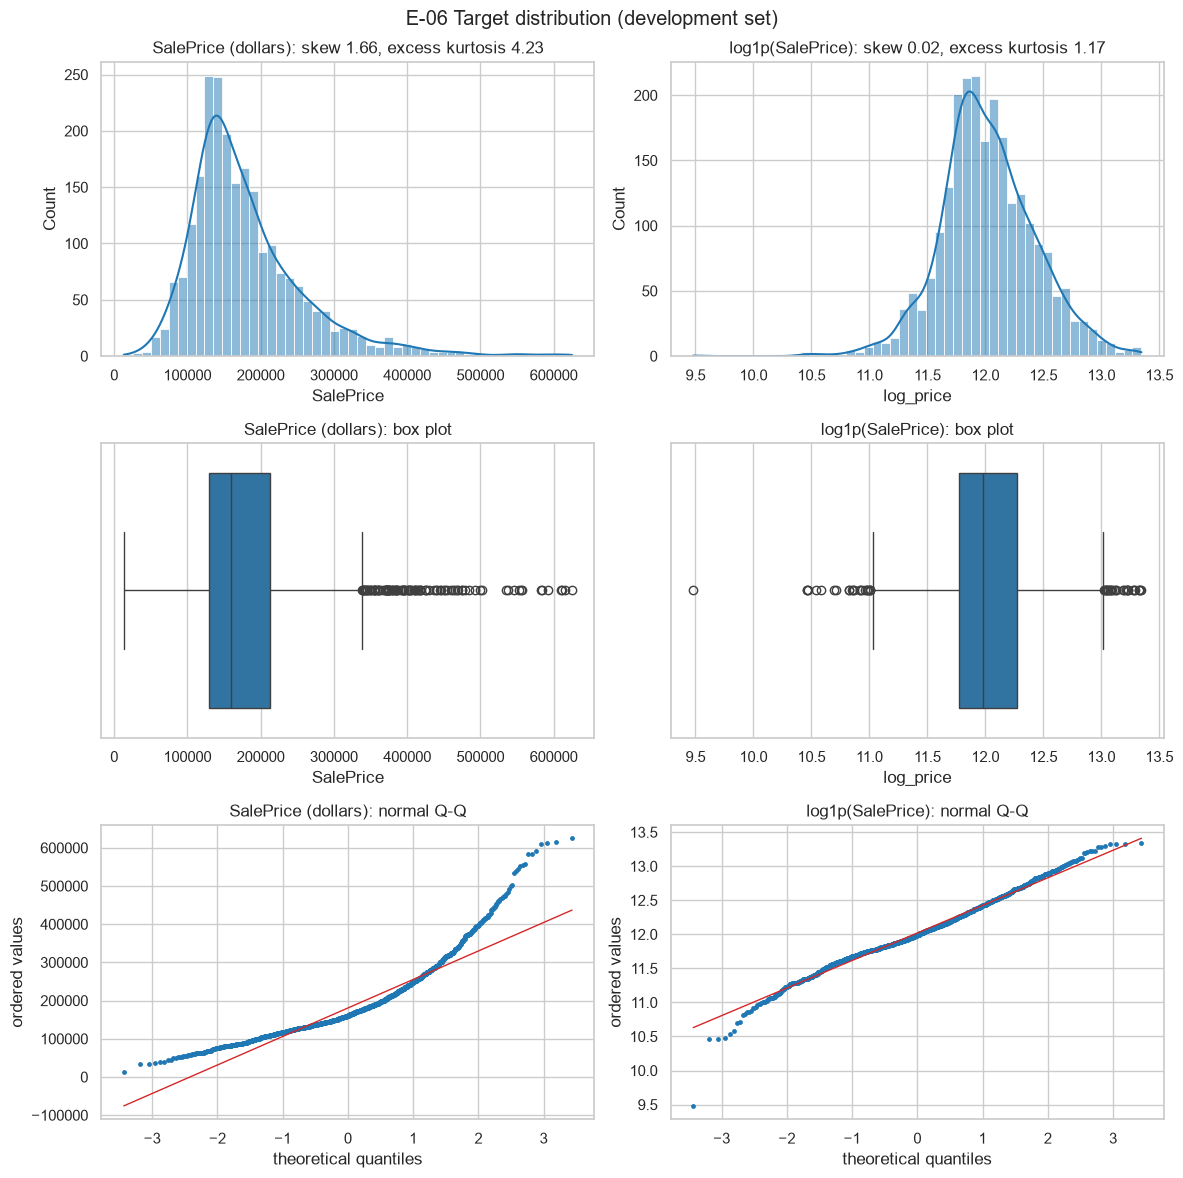

In [4]:
Image(filename=outputs.figures["E-06_target_distribution"])

## E-07 Residual spread versus fitted value (descriptive least-squares fit, not a project model).

In [5]:
outputs.tables["E-07_residual_spread"]

,scale,bin,n,fitted_mean,residual_sd,top_to_bottom_sd_ratio
0,dollars,0,234,75071.562674,24812.569031,2.795579
1,dollars,1,236,111414.564937,18404.484550,2.795579
2,dollars,2,234,128066.735368,26674.968500,2.795579
3,dollars,3,232,147181.508426,27759.757893,2.795579
4,dollars,4,234,165316.908586,27096.671373,2.795579
5,dollars,5,234,184218.342447,27736.413874,2.795579
6,dollars,6,235,203685.468878,30978.602407,2.795579
7,dollars,7,233,225586.516359,36579.680417,2.795579
8,dollars,8,234,253367.509245,41241.774112,2.795579
9,dollars,9,234,312233.775962,69365.508886,2.795579


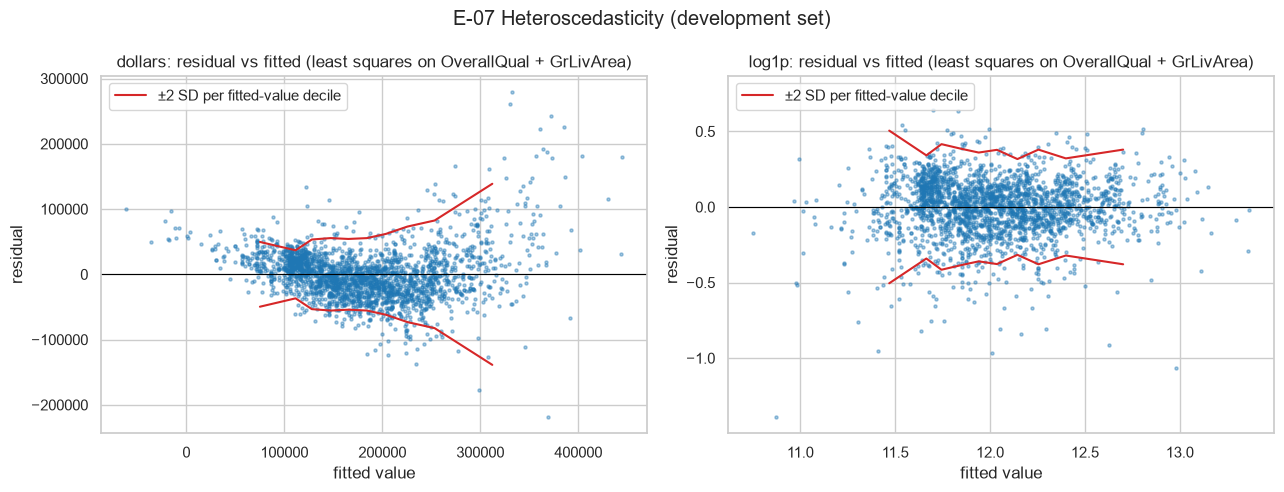

In [6]:
Image(filename=outputs.figures["E-07_heteroscedasticity"])

## E-08 Split balance: share of each log-price decile in the two sets (tolerance 2 pp).

In [7]:
outputs.tables["E-08_split_balance"]

,bin,lower_edge,upper_edge,dev_count,holdout_count,dev_share_pct,holdout_share_pct,diff_pp,within_tolerance
0,0,9.456419,11.563625,234,59,10.0000,10.0855,0.0855,True
1,1,11.563625,11.728045,243,60,10.3846,10.2564,0.1282,True
2,2,11.728045,11.813037,234,59,10.0000,10.0855,0.0855,True
3,3,11.813037,11.894241,225,56,9.6154,9.5726,0.0427,True
4,4,11.894241,11.982935,237,59,10.1282,10.0855,0.0427,True
5,5,11.982935,12.089544,232,58,9.9145,9.9145,0.0000,True
6,6,12.089544,12.203073,233,58,9.9573,9.9145,0.0427,True
7,7,12.203073,12.345839,241,60,10.2991,10.2564,0.0427,True
8,8,12.345839,12.545757,227,57,9.7009,9.7436,0.0427,True
9,9,12.545757,13.345509,234,59,10.0000,10.0855,0.0855,True
